# Lecture 7: Chaos in Maps

## S32 Chaos, Random Processes, and Predictability

Any questions or comments to *milan.kloewer@physics.ox.ac.uk*

Many thanks to Myles Allen and Raymond Pierrehumbert who lectured previous iterations of this material.

In [1]:
# In the following we will embed some pictures that are encoded intro strings
# so there's no additional image file needed, you need to import the following
# to decode those strings into images and display them
from IPython import display
from base64 import b64encode, b64decode

## The Lorenz map (recap)

The Lorenz equations are

$$ \begin{eqnarray}
\dot{x} & = & \sigma (y - x) \\
\dot{y} & = & r x - y - xz \\
\dot{z} & = & xy - bz
\end{eqnarray} $$

with typical values $r = 28, \sigma = 10, b = 8/3$ that yield chaotic solutions. Looked at in the y-z plane

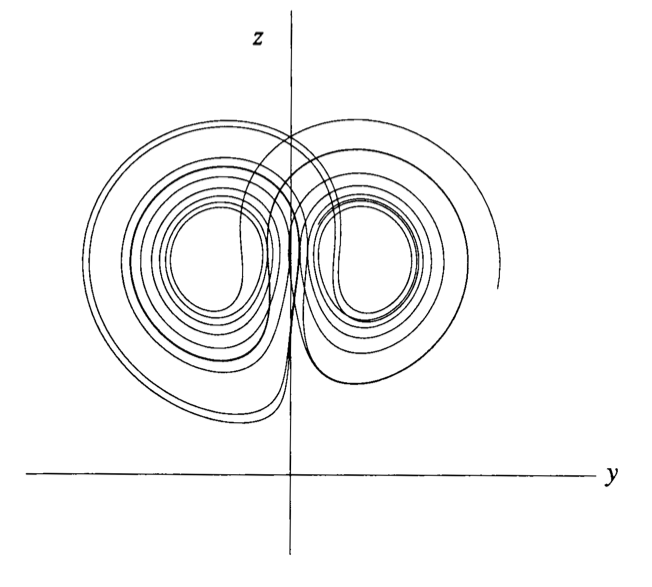

In [2]:
# s = b64encode(open("figures/fig6_3_1.png", "rb").read())
image_string = b'...'
display.Image(b64decode(image_string))

We have two unstable fixed points in the "eyes" of the butterfly wings where trajectories spiral outward from until they "spill over" into the other wing. The larger the amplitude of that (temporary) oscillation in one wing the weaker it starts in the other wing. A time series looks like

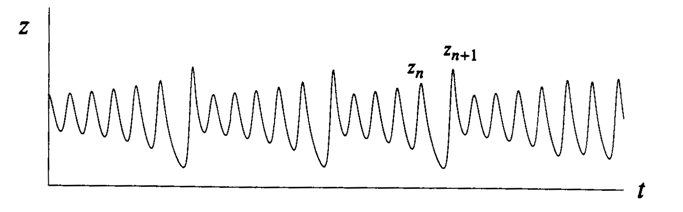

In [3]:
# image_string = b64encode(open("figures/fig6_3_2.png", "rb").read())
image_string = b'...'
display.Image(b64decode(image_string))

So Lorenz had the idea to track the sequence of those maxima $z_n, z_{n+1}$ and think of them as a map (an assumption!)

$$
z_{n+1} = f(z_n)
$$

Which we call the _Lorenz map_. Doing some numerical integrations, finding the maxima, plotting them against another leads to

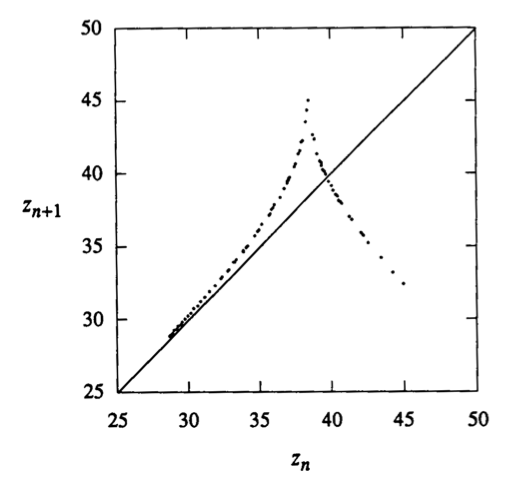

In [4]:
# image_string = b64encode(open("figures/fig6_3_3.png", "rb").read())
image_string = b'...'
display.Image(b64decode(image_string))

Note that the mountain shape here is an approximation: The line isn't perfectly and actually has some width, after all we tried to condense a 3D dynamical system into a 1D discrete map! Recall

- Continuos systems need to be >= 3D for chaos
- Discrete systems can be chaotic with 1 variable already!

## Back to lecture 1: The Logistic Map

The logistic map iteratively applies the map $f(x) = rx(1-x)$ to a value $x_i$

$$ x_{i+1} = r x_i (1 - x_i) $$

In [5]:
import numpy as np

def logistic_map(xᵢ, r):
    return r * xᵢ * (1 - xᵢ)

As this function would only return the next value $x_{i+1}$ given $x_i$ and the growth parameter $r$ we define another function that just loops over $N$ time steps and stores every iteration of the logistic map in a numpy array

In [6]:
def logistic_map_timeseries(x0, r, N):
    x = np.zeros(N)             # allocate vector
    x[0] = x0                   # store initial condition
    for i in range(N-1):
        x[i+1] = logistic_map(x[i], r)

    return x

### Period doubling and bifurcations

Now loop over different values of r, compute a sequence of the logistic map but discard the first half to allow the system to approach its attractor

In [7]:
def logistic_bifurcation(rs, N=100):                     # rs: vector of r values, N iterations of map
    X = np.zeros((N, len(rs)))                           # just save all values of x
    R = np.repeat(rs[None, ...], N, axis=0)              # as well as the corresponding r
    for (ir, r) in enumerate(rs):
        x0 = np.random.rand()                            # start somewhere on the attractor
        x = logistic_map_timeseries(x0, r = r, N = 2*N)  # run for twice as long
        X[:, ir] = x[-N:]                                # but discard first half
    
    return X, R

In [8]:
rs = np.linspace(1, 4, 1000)             # pick a resolution in r
X, R = logistic_bifurcation(rs, N=2000)  # and the number of iterations N to integrate for

Now we just visualise the state of the variable $x$ in the logistic map after some N iterations, what do you expect?

- For a stable fixed point all values of $x$ should correspond (approximately) to that fixed point
- For a periodic solution the values of $x$ should alternate between the points on the periodic orbit
- For a chaotic solution a range of $x$ should be densely covered

Text(0.5, 1.0, 'Logistic map: Bifurcation diagram')

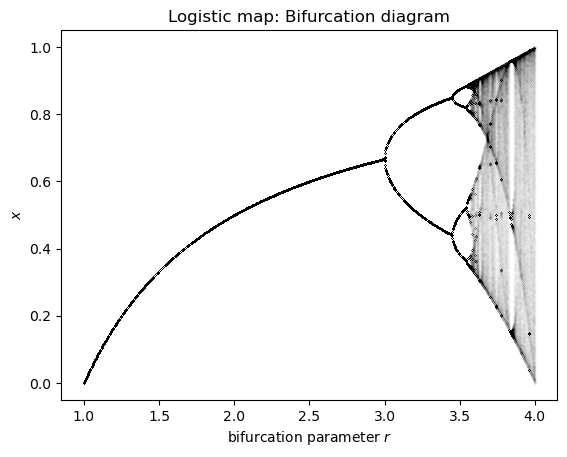

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
ax.scatter(R, X, 0.02, alpha=0.02, c="k")
ax.set_xlabel(r"bifurcation parameter $r$")
ax.set_ylabel(r"$x$")
ax.set_title("Logistic map: Bifurcation diagram")

There are higher resolution version of this [bifurcation diagram](https://en.wikipedia.org/wiki/Logistic_map#/media/File:Logistic_Bifurcation_map_High_Resolution.png) including a [zoomed version](https://en.wikipedia.org/wiki/Logistic_map#/media/File:Subsection_Bifurcation_Diagram_Logistic_Map.png). Some features

- $r=1$, first appearance of a non-zero stable fixed point
- $r=3$, first appearance of a periodic oscillation between two values, or "2-cycle"
- $r=1+\sqrt{6}$, 2-cycle goes unstable, and becomes a stable 4-cycle
- $r=3.54409$..., 4-cycle goes unstable, and becomes a stable 8-cycle
- $r=3.569946$..., period becomes infinite -- non-repeating
- $r=1+\sqrt{8}$, stable 3-cycle appears out of chaos

You can see these islands of stability as empty patches in the bifurcation diagram. You can create bifurcation diagrams for many different chaotic systems, typically with a parameter controlling the solution in the transition to chaos on the x-axis and some summary of the states the system takes (here essentially a histogram of $x$ values) on the y-axis.

#### Food for thought: Feigenbaum numbers

We see that the values of $r$ for which period-doubling bifurcations set in get closer and closer together, reaching an accumulation point (which is right where chaos sets in).  Feigenbaum found the following remarkable property by numerical experiment. Let $r_n$ be the value of $r$ for which the $n$-th period-doubling bifurcation occurs.  Then

$$\lim_{n\to\infty} \frac{r_n - r_{n-1}}{r_{n+1} - r_n} = 4.669....$$

approaches a universal value which is independent of the map.  For other maps use $r$ becomes the respective bifurcation parameter. E.g. using the bifurcations from above

$$r_0 = 1$$
$$r_1 = 3$$
$$r_2 = 1 + \sqrt{6}$$
$$r_3 = 3.54409...$$



We are already very close

$$\frac{r_2 - r_1}{r_3 - r_2} = 4.75 ...$$

## Bifurcation in the tent map

Another example of a chaotic map is the tent map defined by

$$
x_{i+1} = f(x_i) = \mu \min(x_i, 1-x_i)
$$

Which is called a tent map because it looks like one! E.g. for $\mu = 1.9$ we have the following cobweb plot

In [10]:
def tent_map(xᵢ, μ):
    return μ*np.minimum(xᵢ, 1 - xᵢ)  # use np.minimum instead of min as it works for scalars and vectors

def tent_map_timeseries(x0, μ, N):
    x = np.zeros(N)                  # allocate vector
    x[0] = x0                        # store initial condition
    for i in range(N-1):
        x[i+1] = tent_map(x[i], μ)

    return x

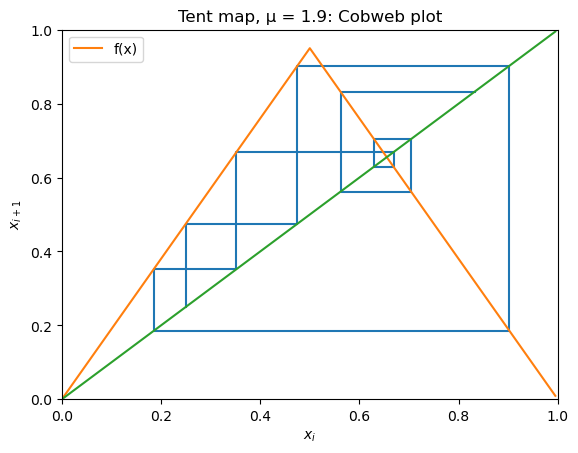

In [11]:
μ = 1.9
x = tent_map_timeseries(x0=0.25, μ=μ, N=10)
xx = np.repeat(x, 2)      # repeat x values to reuse i+1 for i in the next year
plt.plot(xx[:-1], xx[1:]) # plot in a staggered way to create cobweb "walking"

# add a line and quadratic curve following r
xs = np.arange(0, 1, 0.005)
plt.plot(xs, tent_map(xs, μ=μ), label='f(x)')
plt.plot(xs, xs)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r'$x_i$')
plt.ylabel(r'$x_{i+1}$')
plt.title('Tent map, μ = {}: Cobweb plot'.format(μ))
plt.legend()

So the orange triangle here resembles a tent, hence the name. The logic of the cobweb plot is as before:

1. Map $x_i$ to the tent (straight line up/down till you hit the orange)
2. Go horizontally till you hit the $x_{i+1} = x_i$ line (this corresponds to the next iterations where $i \to i+1$)
3. Repeat from 1.

So what is the role of the parameter $\mu$ in this map? Let us create a bifurcation diagram similar to before

In [12]:
def tent_bifurcation(μs, N=100):                         # μs: vector of μ values, N iterations of map
    X = np.zeros((N, len(μs)))                           # just save all values of x
    M = np.repeat(μs[None, ...], N, axis=0)              # as well as the corresponding μ
    for (iμ, μ) in enumerate(μs):
        x0 = np.random.rand()                            # start somewhere on the attractor
        x = tent_map_timeseries(x0, μ = μ, N = 2*N)      # run for twice as long
        X[:, iμ] = x[-N:]                                # but discard first half
    
    return X, M

In [13]:
μs = np.linspace(1, 2, 1000)             # pick a resolution in μ
X, M = tent_bifurcation(μs, N=2000)      # and the number of iterations N to integrate for

Text(0.5, 1.0, 'Tent map: Bifurcation diagram')

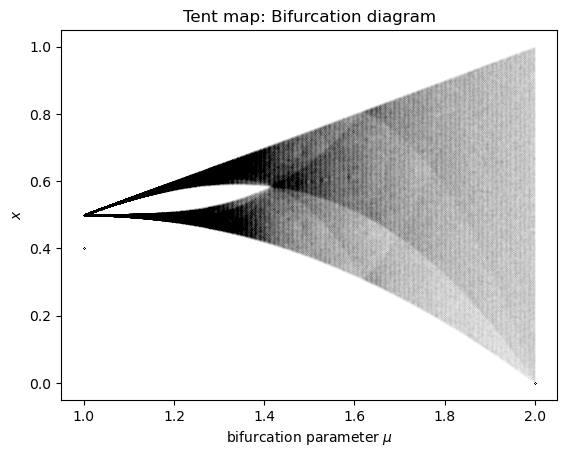

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
ax.scatter(M, X, 0.02, alpha=0.02, c="k")
ax.set_xlabel(r"bifurcation parameter $\mu$")
ax.set_ylabel(r"$x$")
ax.set_title("Tent map: Bifurcation diagram")

# The Mandelbrot set

The Mandelbrot set is defined as the set of complex numbers $c$ for which the map

$$z_{i+1} = z_i^2 + c$$

iterating over a complex number $z = x + yj$, stays bounded, $\vert z \vert^2 = x^2 + y^2 < \infty$. The initial condition is $z_0 = 0$ for all $c$. Note we use $j$ here as the imaginary unit as this is the notation that Python also uses.

### Some Mandelbrot sequences

Let's explore this map with a few initial conditions and iterations

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def mandelbrot_map(c, N):
    z = np.zeros(N, dtype=complex)   # return the sequence as vector
    for i in range(N-1):             # iterate over the map
        z[i+1] = z[i]**2 + c         # store in next element in vector
    return z

What about c = 1? We try simply $N = 10$ iterations of the map

In [17]:
mandelbrot_map(c = 1, N = 10)

array([0.00000000e+00+0.j, 1.00000000e+00+0.j, 2.00000000e+00+0.j,
       5.00000000e+00+0.j, 2.60000000e+01+0.j, 6.77000000e+02+0.j,
       4.58330000e+05+0.j, 2.10066389e+11+0.j, 4.41278877e+22+0.j,
       1.94727048e+45+0.j])

Well that blew up quickly! What about $c = -1$?

In [18]:
mandelbrot_map(c = -1, N = 12)

array([ 0.+0.j, -1.+0.j,  0.+0.j, -1.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,
       -1.+0.j,  0.+0.j, -1.+0.j,  0.+0.j, -1.+0.j])

Clearly the sequence remains bounded, in fact it's periodic 0, -1, 0, -1, etc! So $c=-1$ is part of the Mandelbrot set! Now let us use $c = 0.5j$, with non-zero imaginary part! Why would that be any different?

In [19]:
z = mandelbrot_map(c = 0 + 0.5*1j, N=16)
z

array([ 0.        +0.j        ,  0.        +0.5j       ,
       -0.25      +0.5j       , -0.1875    +0.25j      ,
       -0.02734375+0.40625j   , -0.16429138+0.4777832j ,
       -0.20128513+0.34300867j, -0.07713925+0.36191491j,
       -0.12503194+0.44416431j, -0.18164895+0.38893055j,
       -0.11827063+0.35870235j, -0.11467943+0.41515209j,
       -0.15919989+0.40478119j, -0.13850321+0.37111776j,
       -0.11854525+0.397198j  , -0.14371328+0.40582812j])

Can we visualise this?

Text(0.5, 1.0, 'Mandelbrot sequence for $c = 0.5j$')

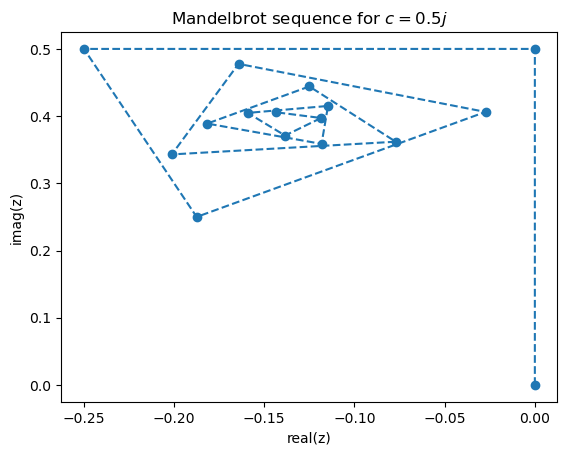

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
ax.plot(np.real(z), np.imag(z), "o--")
ax.set_xlabel("real(z)")
ax.set_ylabel("imag(z)")
ax.set_title(r"Mandelbrot sequence for $c = 0.5j$")

So this clearly seems to converge to some fixed point, spiralling inwards. Note that powers of complex numbers are computed as 

$$ z^n = (r(\cos \varphi + j \sin \varphi)^n) = r^n (\cos n\varphi + j \sin n\varphi)$$

This is of course not exactly what's happening here as the Mandelbrot map is defined with an additional $+ c$ but this is where the spiral comes from! 

### Visualising the Mandelbrot set

Let's setup a grid to compute many values of the parameter c simultaneously

In [21]:
width, height = 1200, 1200   # resolution in pixels
x_min, x_max = -2.0, 1.0     # range of c values
y_min, y_max = -1.5, 1.5
N = 30                       # number of iterations
unbounded = 1e30             # values above which are considered "unbounded" to avoid numerical overflow!

# set up a grid of parameters c, C = X + Yj
x = np.linspace(x_min, x_max, width)
y = np.linspace(y_min, y_max, height)
X, Y = np.meshgrid(x, y)
C = X + 1j * Y
Z = np.zeros_like(C)         # initial conditions Z = 0 + 0j for every c in C!

Now iterate over the Mandelbrot map

In [22]:
for i in range(N):
    Z = Z**2 + C                        # iterate over the map for all elements in the array
    Z[abs(Z) >= unbounded] = unbounded  # to avoid overflows, we just cap large values to "unbounded"

Text(0.5, 1.0, 'Mandelbrot set')

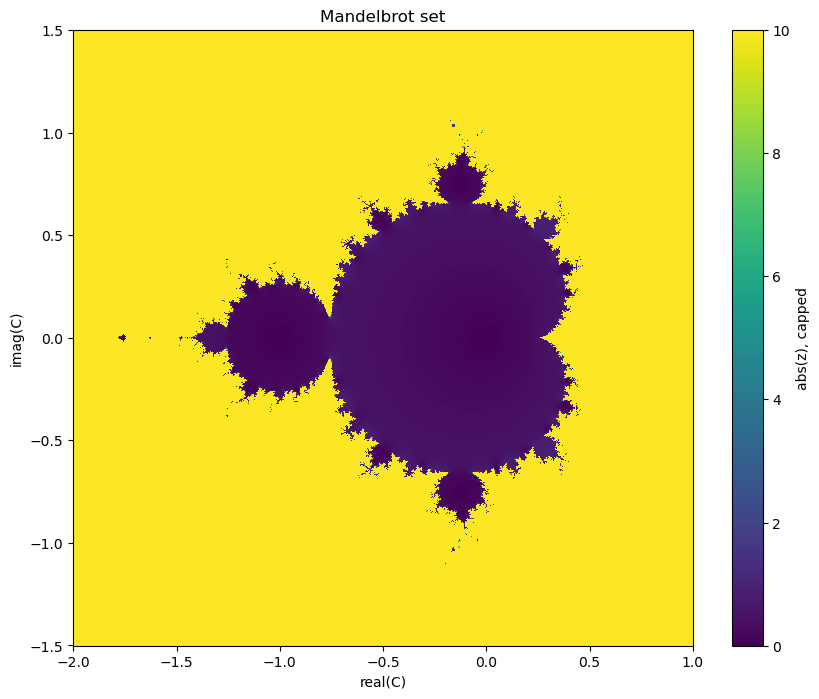

In [23]:
fig, ax = plt.subplots(1, 1, figsize= (10, 8))
q = ax.pcolormesh(X, Y, abs(Z), vmin=0, vmax=10)
c = plt.colorbar(q, ax=ax, label="abs(z), capped")
ax.set_xlabel("real(C)")
ax.set_ylabel("imag(C)")
ax.set_title("Mandelbrot set")

Wow! How such a simple equation can produce such complexity. With colour we here now visualise the absolute value of $z_N$, the value of the sequence after $N$ iterations. This value is capped, we don't really care about the exact value but just want to distinguish bounded vs unbounded solutions. As our "initial conditions" $c$ are O(1) we simply consider everthing O(10) to be unbounded. So now every pixel that is yellow blew up and is not part of the Mandelbrot set, all purple pixels remained bounded and are part of the Mandelbrot set. Can we zoom in?

In [24]:
width, height = 1200, 1200   # resolution in pixels
x_min, x_max = -0.25, -0.15  # range of c values
y_min, y_max = 0.6, 0.7
N = 100                      # number of iterations
unbounded = 1e30             # values above which are considered "unbounded" to avoid numerical overflow!

# set up a grid of parameters c, C = X + Yj
x = np.linspace(x_min, x_max, width)
y = np.linspace(y_min, y_max, height)
X, Y = np.meshgrid(x, y)
C = X + 1j * Y
Z = np.zeros_like(C)         # initial conditions Z = 0 + 0j for every c in C!

In [25]:
for i in range(N):
    Z = Z**2 + C                        # iterate over the map for all elements in the array
    Z[abs(Z) >= unbounded] = unbounded  # to avoid overflows, we just cap large values to "unbounded"

Text(0.5, 1.0, 'Mandelbrot set, zoomed in')

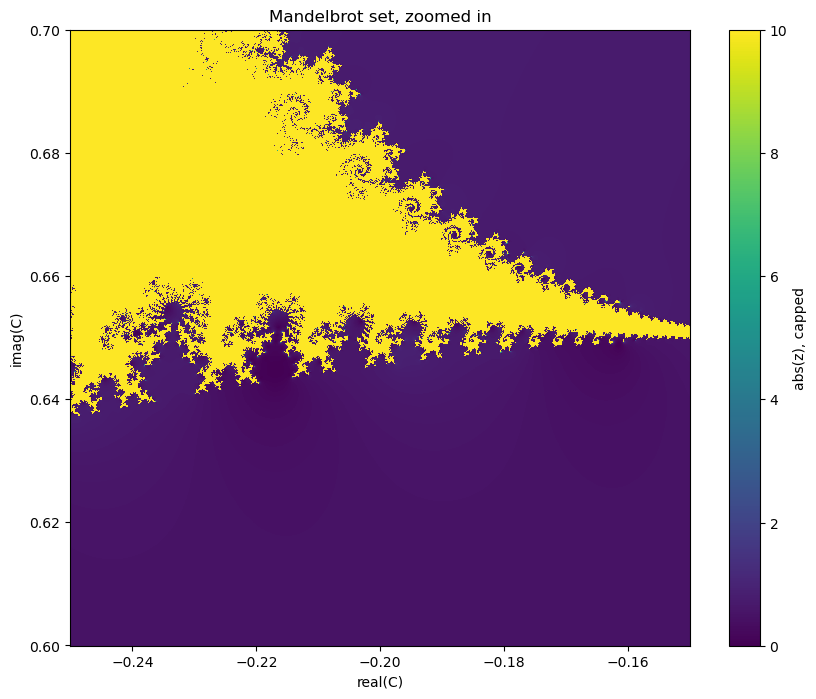

In [26]:
fig, ax = plt.subplots(1, 1, figsize= (10, 8))
q = ax.pcolormesh(X, Y, abs(Z), vmin=0, vmax=10)
c = plt.colorbar(q, ax=ax, label="abs(z), capped")
ax.set_xlabel("real(C)")
ax.set_ylabel("imag(C)")
ax.set_title("Mandelbrot set, zoomed in")

Zooming in many features of chaos and fractals become apparent:

- Sensitivity to initial conditions. As we zoomed in, the differences in the initial conditions is tiny yet can lead to a bounded or unbounded solution
- Self-similarity. Many patterns seen in large repeat themselves in small, this is also something we observe in turbulence where bigger whirls consist of smaller whirls and so on.

More sophisticated zooms are found on [YouTube](https://youtu.be/CfqHAOOM8Tw?si=Csra9YIeSKJMk31X).